# MAE reconstruction quality check — `checkpoint_epoch44.pt`

Loss curves alone can hide "technically low error but visually mush" reconstructions.
This notebook loads the SSL-pretrained checkpoint, runs a real tile through it, and
plots original vs. reconstructed side by side so we can actually judge quality by eye
before building the downstream fine-tuning head on top of this checkpoint.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.dataset import load_tile, normalize, random_crop
from src.models.mae import MaskedAutoencoder, adapt_patch_embed
import timm

/Users/Aiden/Desktop/portfolio/palmTrack/files/ticino-palm-mapper/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load checkpoint and rebuild the model

In [2]:
CHECKPOINT_PATH = PROJECT_ROOT / "checkpoints" / "checkpoint_epoch44.pt"

# Same architecture config used in src/training/pretrain_ssl.py's main() —
# must match exactly, since load_state_dict needs identical shapes.
BACKBONE_NAME = "vit_small_patch14_dinov2.lvd142m"
IN_CHANS = 4
IMG_SIZE = 224
PATCH_SIZE = 14
EMBED_DIM = 384
DECODER_EMBED_DIM = 192
DECODER_DEPTH = 4
DECODER_NUM_HEADS = 6
MASK_RATIO = 0.75

device = torch.device("cpu")  # inference-only, no need for GPU/MPS here

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
stats = checkpoint["stats"]
print(f"checkpoint epoch: {checkpoint['epoch']}")
print(f"stats mean: {stats.mean}, std: {stats.std}")

backbone = timm.create_model(BACKBONE_NAME, pretrained=False)  # weights get overwritten below
backbone = adapt_patch_embed(backbone, IN_CHANS)

model = MaskedAutoencoder(
    backbone, IMG_SIZE, PATCH_SIZE, IN_CHANS, EMBED_DIM,
    DECODER_EMBED_DIM, DECODER_DEPTH, DECODER_NUM_HEADS, MASK_RATIO,
)
model.backbone.patch_embed.strict_img_size = False
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()
print("model loaded")

checkpoint epoch: 44
stats mean: [60.77492347 85.27332511 56.34801307  4.85546222], std: [77.59957957 77.60017143 67.47403153 28.15407711]


model loaded


## Load and preprocess one real tile

In [3]:
tile_dir = PROJECT_ROOT / "data/processed/lugano_example/feature_stack"
tile_paths = sorted(tile_dir.glob("*_rgbchm.tif"))
print(f"{len(tile_paths)} tiles available")

tile_path = tile_paths[0]  # change the index to look at a different tile
arr, transform, crs = load_tile(tile_path)
arr = normalize(arr, stats)

rng = np.random.default_rng(0)
crop, _ = random_crop(arr, np.zeros(arr.shape[1:]), IMG_SIZE, rng)  # dummy target, unused here

x = torch.from_numpy(crop).float().unsqueeze(0)  # (1, C, H, W)
print(f"input shape: {x.shape}")

36 tiles available


input shape: torch.Size([1, 4, 224, 224])


## Run inference

In [4]:
with torch.no_grad():
    loss, pred, mask = model(x)

print(f"reconstruction loss on this crop: {loss.item():.4f}")
print(f"pred shape: {pred.shape}, mask shape: {mask.shape}")

reconstruction loss on this crop: 0.1475
pred shape: torch.Size([1, 256, 784]), mask shape: torch.Size([1, 256])


## Reconstruct images for visualization

`unpatchify` is the inverse of `MaskedAutoencoder.patchify` — same reshape/permute
logic, run backwards, to turn per-patch pixel vectors back into a (C, H, W) image.

Three panels: the original crop, a "masked" view (visible patches only, masked ones
blacked out, i.e. literally what the encoder saw), and the reconstruction (predicted
pixels at masked positions, original pixels at visible positions — standard MAE-paper
visualization, since the model was never asked to predict the visible patches).

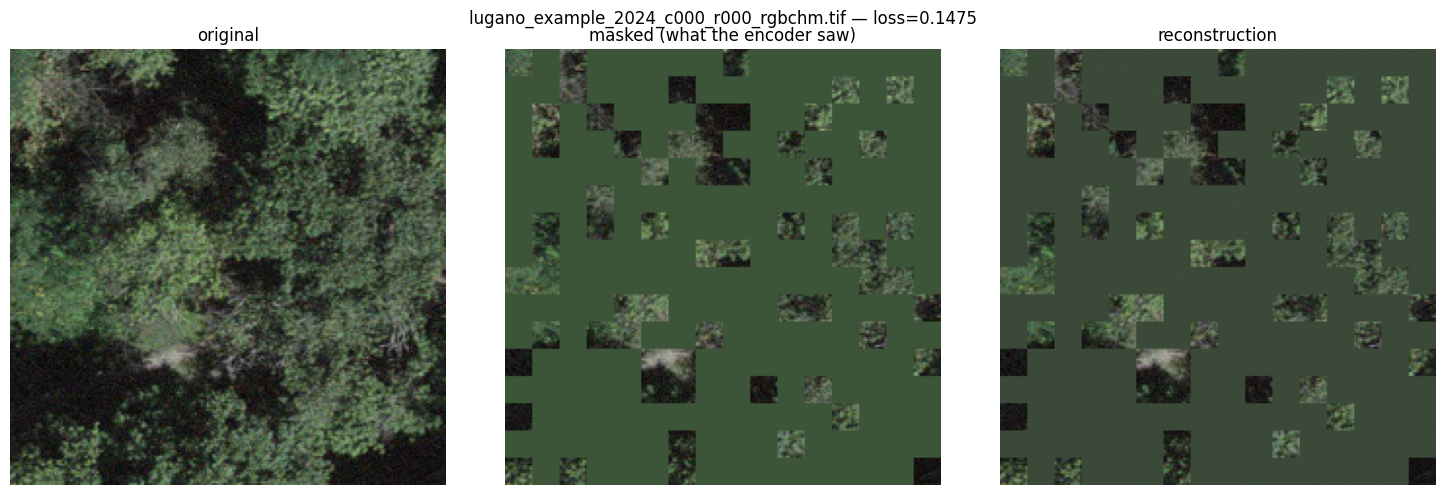

In [5]:
def unpatchify(tens: torch.Tensor, patch_size: int, h: int, w: int, C: int) -> torch.Tensor:
    B = tens.shape[0]
    p = patch_size
    tens = tens.reshape(B, h, w, p, p, C)
    tens = tens.permute(0, 5, 1, 3, 2, 4)
    tens = tens.reshape(B, C, h * p, w * p)
    return tens


h = w = IMG_SIZE // PATCH_SIZE

target_patches = model.patchify(x)  # (1, N, p*p*C) — ground truth in patch layout

# masked view: original pixels where visible (mask==0), zero where masked (mask==1)
masked_patches = target_patches * (1 - mask.unsqueeze(-1))

# reconstruction: predicted pixels where masked, original pixels where visible
recon_patches = pred * mask.unsqueeze(-1) + target_patches * (1 - mask.unsqueeze(-1))

original_img = unpatchify(target_patches, PATCH_SIZE, h, w, IN_CHANS)
masked_img = unpatchify(masked_patches, PATCH_SIZE, h, w, IN_CHANS)
recon_img = unpatchify(recon_patches, PATCH_SIZE, h, w, IN_CHANS)


def denorm_rgb(img: torch.Tensor) -> np.ndarray:
    """(1, C, H, W) normalized tensor -> (H, W, 3) uint8 RGB for display."""
    arr = img[0, :3].detach().numpy()  # first 3 channels are R, G, B
    mean = stats.mean[:3].reshape(3, 1, 1)
    std = stats.std[:3].reshape(3, 1, 1)
    arr = arr * std + mean  # undo normalize()
    arr = np.clip(arr, 0, 255).astype(np.uint8)
    return np.transpose(arr, (1, 2, 0))  # (H, W, C) for matplotlib


panels = [
    ("original", denorm_rgb(original_img)),
    ("masked (what the encoder saw)", denorm_rgb(masked_img)),
    ("reconstruction", denorm_rgb(recon_img)),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, img) in zip(axes, panels):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
fig.suptitle(f"{tile_path.name} — loss={loss.item():.4f}")
plt.tight_layout()
plt.show()